In [183]:
import numpy as np
import pandas as pd

In [184]:
df = pd.read_csv('iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [185]:
df = df.iloc[:,1:]

In [186]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [187]:
from sklearn.preprocessing import LabelEncoder

In [188]:
encoder = LabelEncoder()

In [189]:
df['Species'] = encoder.fit_transform(df['Species'])

In [190]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [191]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [192]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [206]:
import seaborn as sns
import matplotlib.pyplot as plt

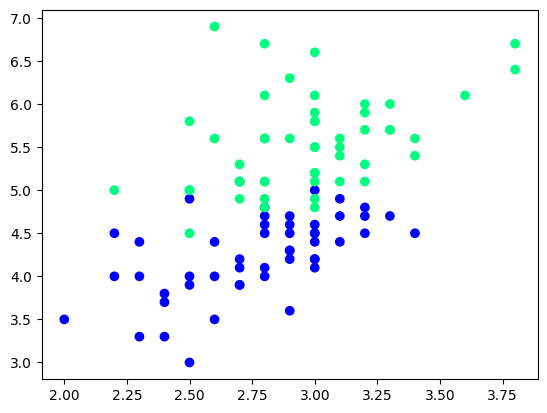

In [194]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'], cmap='winter')

In [195]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
73,2.8,4.7,1
91,3.0,4.6,1
106,2.5,4.5,2
80,2.4,3.8,1
88,3.0,4.1,1
62,2.2,4.0,1
58,2.9,4.6,1
63,2.9,4.7,1
109,3.6,6.1,2
99,2.8,4.1,1


In [196]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)


In [197]:
df_train

,SepalWidthCm,PetalLengthCm,Species
130,2.8,6.1,2
131,3.8,6.4,2
55,2.8,4.5,1
118,2.6,6.9,2
123,2.7,4.9,2
88,3.0,4.1,1
132,2.8,5.6,2
125,3.2,6.0,2
82,2.7,3.9,1
122,2.8,6.7,2


In [198]:
df_val

,SepalWidthCm,PetalLengthCm,Species
67,2.7,4.1,1
63,2.9,4.7,1
96,2.9,4.2,1
106,2.5,4.5,2
109,3.6,6.1,2


In [199]:
df_test

,SepalWidthCm,PetalLengthCm,Species
149,3.0,5.1,2
87,2.3,4.4,1
60,2.0,3.5,1
81,2.4,3.7,1
140,3.1,5.6,2


In [200]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values
y_test

array([1, 1, 1, 2, 2])

Case 1: Bagging

In [201]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
82,2.7,3.9,1
131,3.8,6.4,2
132,2.8,5.6,2
88,3.0,4.1,1
132,2.8,5.6,2
132,2.8,5.6,2
130,2.8,6.1,2
130,2.8,6.1,2


In [202]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score


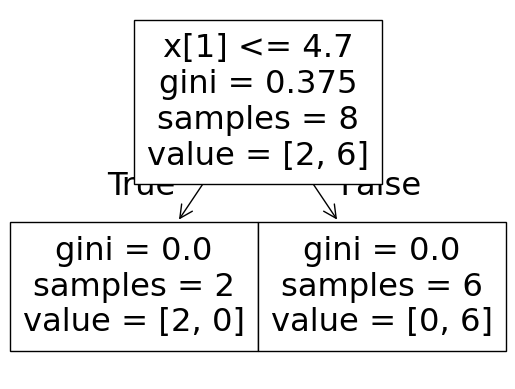

0.8


C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


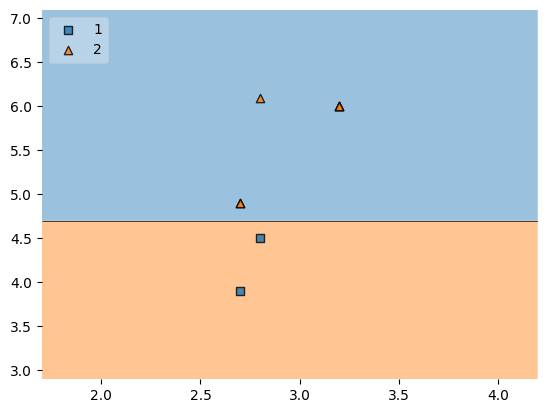

In [215]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)

In [211]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
82,2.7,3.9,1
55,2.8,4.5,1
123,2.7,4.9,2
123,2.7,4.9,2
125,3.2,6.0,2
125,3.2,6.0,2
130,2.8,6.1,2
125,3.2,6.0,2


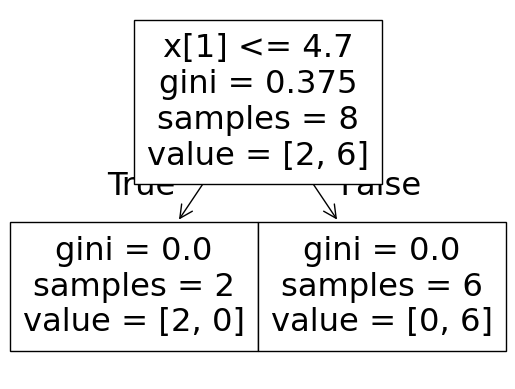

0.8


C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


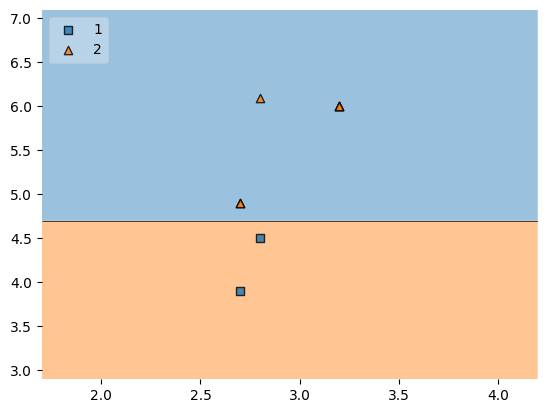

In [216]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [209]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
88,3.0,4.1,1
82,2.7,3.9,1
122,2.8,6.7,2
55,2.8,4.5,1
82,2.7,3.9,1
55,2.8,4.5,1
132,2.8,5.6,2
118,2.6,6.9,2


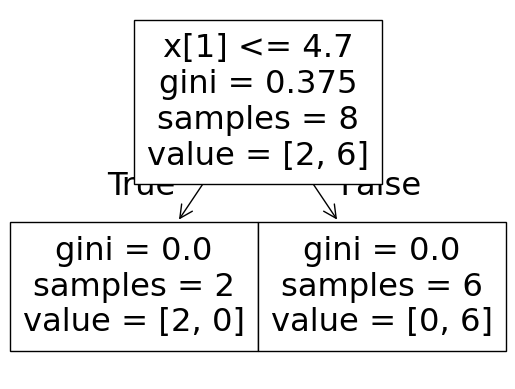

0.8


C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


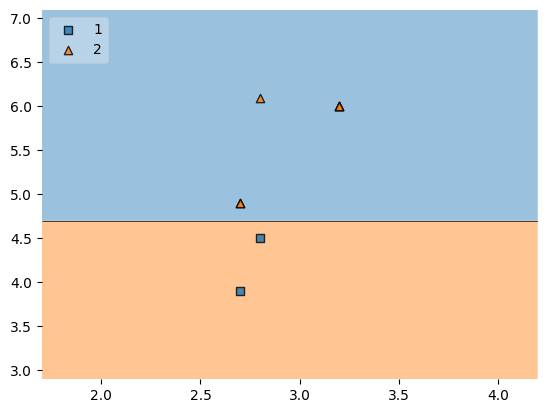

In [217]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [205]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))


Predict

In [219]:
df_test

,SepalWidthCm,PetalLengthCm,Species
149,3.0,5.1,2
87,2.3,4.4,1
60,2.0,3.5,1
81,2.4,3.7,1
140,3.1,5.6,2


In [220]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Pasting

In [221]:
df_train

,SepalWidthCm,PetalLengthCm,Species
130,2.8,6.1,2
131,3.8,6.4,2
55,2.8,4.5,1
118,2.6,6.9,2
123,2.7,4.9,2
88,3.0,4.1,1
132,2.8,5.6,2
125,3.2,6.0,2
82,2.7,3.9,1
122,2.8,6.7,2


In [222]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
123,2.7,4.9,2
55,2.8,4.5,1
130,2.8,6.1,2
132,2.8,5.6,2
131,3.8,6.4,2
118,2.6,6.9,2
122,2.8,6.7,2
125,3.2,6.0,2


Random Subspaces

In [223]:
df1 = pd.read_csv('iris.csv')
df1 = df1.sample(10)

In [224]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
132,133,6.4,2.8,5.6,2.2,Iris-virginica
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
74,75,6.4,2.9,4.3,1.3,Iris-versicolor
146,147,6.3,2.5,5.0,1.9,Iris-virginica
16,17,5.4,3.9,1.3,0.4,Iris-setosa
149,150,5.9,3.0,5.1,1.8,Iris-virginica
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
44,45,5.1,3.8,1.9,0.4,Iris-setosa
92,93,5.8,2.6,4.0,1.2,Iris-versicolor


In [225]:
df1.sample(2,replace=True,axis=1)

,Species,SepalWidthCm
83,Iris-versicolor,2.7
132,Iris-virginica,2.8
76,Iris-versicolor,2.8
74,Iris-versicolor,2.9
146,Iris-virginica,2.5
16,Iris-setosa,3.9
149,Iris-virginica,3.0
77,Iris-versicolor,3.0
44,Iris-setosa,3.8
92,Iris-versicolor,2.6


Random Patches

In [226]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
132,133,6.4,2.8,5.6,2.2,Iris-virginica
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
74,75,6.4,2.9,4.3,1.3,Iris-versicolor
146,147,6.3,2.5,5.0,1.9,Iris-virginica
16,17,5.4,3.9,1.3,0.4,Iris-setosa
149,150,5.9,3.0,5.1,1.8,Iris-virginica
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
44,45,5.1,3.8,1.9,0.4,Iris-setosa
92,93,5.8,2.6,4.0,1.2,Iris-versicolor


In [227]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalLengthCm,Id
77,5.0,78
76,4.8,77
76,4.8,77
16,1.3,17
146,5.0,147
16,1.3,17
44,1.9,45
83,5.1,84
